# Detecção de Pneumonia em Raio-X com CNN (Rede neural convolucional)

## Objetivo
Construir um modelo de Deep Learning capaz de classificar imagens
de raio-X de tórax em Normal ou Pneumonia.

## Bibliotecas utilizadas
- Python
- TensorFlow / Keras
- OpenCV
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn

## Instalando e importando bibliotecas

In [1]:
!pip install tensorflow
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 858.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 109.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 19.2 MB/s eta 0:00:00


In [2]:
import json
import os
import random
import shutil
from pathlib import Path
import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import tensorflow as tf
from google.colab import drive

drive.mount("/content/drive")

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Mounted at /content/drive


## Definindo funções no algoritmo

### **processa_imagem**  
Função que padroniza todas as imagens de uma pasta. Ela retorna um array com as imagens processadas e outro com os rótulos.

### **predicar**
Função de predição responsável por alterar a imagem para o padrão do treinamento e classificar.

### **predizer_pasta**
Função para interpreta os acertos e erros da IA.  
Ao fim da execução, o algoritmo retorna as estatisticas de desempenho e uma matriz de confusão.

In [3]:
def processa_imagem(caminho_imagem):
  imagens = []
  rotulos = []
  arquivos = [os.path.join(caminho_imagem, img) for img in os.listdir(caminho_imagem)]
  for i in arquivos:
    img = cv2.imread(i, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128,128))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=-1)
    imagens.append(img)
    rotulos.append(1 if "PNEUMONIA" in i else 0)
  return np.array(imagens), np.array(rotulos)

In [4]:
def predicar(caminho):
  img = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
  img = cv2.resize(img, (128,128))
  clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
  img = clahe.apply(img)
  img = img.astype("float32") / 255.0
  img = np.expand_dims(img, axis=-1)
  img = np.expand_dims(img, axis=0)
  pred = model.predict(img, verbose=0)
  classe = int(np.argmax(pred))
  return classe

In [14]:
def predizer_pasta(caminho_pasta, predicar):
    res = []
    predicao_normal, predicao_pneumonia, real_normal, real_pneumonia = 0, 0, 0, 0
    verdadeiro_negativo, falso_positivo = 0, 0
    falso_negativo, verdadeiro_positivo = 0, 0

    nome_arquivo = os.listdir(caminho_pasta)

    for imagem in sorted(nome_arquivo):
        caminho_inteiro = os.path.join(caminho_pasta, imagem)
        resposta = -1
        prediz = predicar(caminho_inteiro)

        if prediz == 0:
            #print('Normal', end='\t')
            predicao_normal += 1
            resposta = 0
        else:
            #print('Pneumonia', end='\t')
            predicao_pneumonia += 1
            resposta = 1

        if 'NORMAL' in imagem:
            #print(imagem, end='\t')
            rotulo_real = 0
            real_normal += 1
        else:
            #print(imagem, end='\t')
            rotulo_real = 1
            real_pneumonia += 1

        res.append(resposta == rotulo_real)

        if resposta == rotulo_real:
            if resposta == 0:
                verdadeiro_negativo += 1
                #print("Acertou")
            else:
                verdadeiro_positivo += 1
                #print("Acertou")
        else:
            if resposta == 0:
                falso_negativo += 1
                #print("Errou")
            else:
                falso_positivo += 1
                #print("Errou")

    acuracia = res.count(True) / len(res) if res else 0
    print('\nAcurácia: ', acuracia)
    print('Predito como normal: ', predicao_normal)
    print('Predito como pneumonia: ', predicao_pneumonia)
    print('Quantidade real de normal: ', real_normal)
    print('Quantidade real de pneumonia: ', real_pneumonia)

    print('\nAcertos de Normal: ', verdadeiro_negativo)
    print('Acertos de Pneumonia: ', verdadeiro_positivo)
    print('Normal predito como pneumonia: ', falso_positivo)
    print('Pneumonia predito como normal: ', falso_negativo)

    cm = np.array([[verdadeiro_negativo, falso_positivo], [falso_negativo, verdadeiro_positivo]])
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
    plt.ylabel('Real')
    plt.xlabel('Predito')
    plt.title('Matriz de Confusão')
    plt.show()

## Carregando e processando imagens para treino
### **etapas de pré-processamento**
- Conversão para escala de cinza
- Redimensionamento para 128x128
- Aplicação de CLAHE
- Normalização

In [6]:
caminho = "/content/drive/MyDrive/treino"
imagens, rotulos = processa_imagem(caminho)
print(imagens.shape)
print(rotulos.shape)

(5910, 128, 128, 1)
(5910,)


In [7]:
# Separando as imagens em dados de treino, teste e validação
x_treino, x_temporario, y_treino, y_temporario = train_test_split(imagens, rotulos, test_size=0.3, random_state=42)
x_validacao, x_teste, y_validacao, y_teste = train_test_split(x_temporario, y_temporario, test_size=0.5, random_state=42)

## Arquitetura do Modelo
- CNN com 3 blocos convolucionais
- Batch Normalization
- Dropout
- Softmax

## Treinamento
- Otimizador: Adam
- Loss: SparseCategoricalCrossentropy
- EarlyStopping

In [9]:
# Montando o modelo sequencial
model = models.Sequential()

# Primeira camada convolucional com 64 filtros e tamanho 3x3, input shape corresponde o tamanho das imagens que entram na IA
model.add(layers.Conv2D(64, (3, 3), activation='relu', input_shape=(128, 128, 1)))

# Aplica uma operação de pooling com uma janela 2x2 para reduzir as dimensões da imagem
model.add(layers.MaxPooling2D((2, 2)))

# Normaliza os valores das ativações, ajuda a estabilizar o treinamento
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.BatchNormalization())

# Aumenta o número de filtros para 128, ajuda a capturar mais características das imagens
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.BatchNormalization())

# Flatten transforma a saída das camadas convolucionais em um vetor 1D, necessário para as camadas densas
model.add(layers.Flatten())

# A camada densa tem 128 neurônios, ela irá aprender combinações das características extraídas pelas camadas convolucionais
model.add(layers.Dense(128, activation='relu'))

# A camada de dropout desliga aleatoriamente 50% das conexões durante o treinamento, ajudando a evitar o overfitting
model.add(layers.Dropout(0.5))
model.add(layers.Dense(2, activation='softmax'))

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

Epoch 1/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 92s 696ms/step - accuracy: 0.8456 - loss: 0.9520 - val_accuracy: 0.5102 - val_loss: 4.7749
Epoch 2/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 88s 678ms/step - accuracy: 0.9215 - loss: 0.2374 - val_accuracy: 0.5102 - val_loss: 10.0795
Epoch 3/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 88s 676ms/step - accuracy: 0.9407 - loss: 0.1855 - val_accuracy: 0.5982 - val_loss: 2.7145
Epoch 4/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 89s 681ms/step - accuracy: 0.9616 - loss: 0.1160 - val_accuracy: 0.8431 - val_loss: 0.4171
Epoch 5/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 89s 684ms/step - accuracy: 0.9652 - loss: 0.0853 - val_accuracy: 0.8397 - val_loss: 0.4611
Epoch 6/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 90s 693ms/step - accuracy: 0.9693 - loss: 0.0975 - val_accuracy: 0.9650 - val_loss: 0.1182
Epoch 7/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 89s 686ms/step - accuracy: 0.9665 - loss: 0.0983 - val_accuracy: 0.9740 - val_loss: 0.0938
Epoch 8/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 90s 693ms/step - accuracy: 0.9743 - loss: 

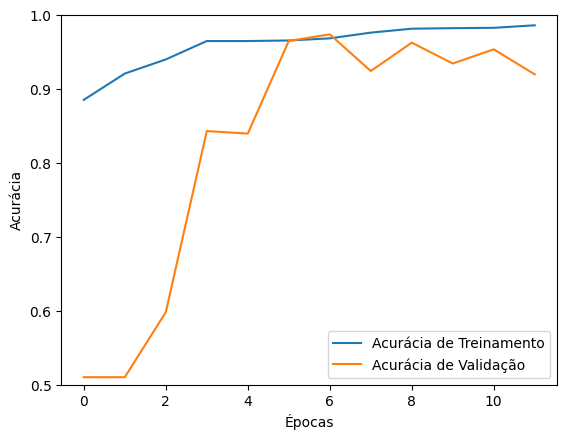

In [10]:
history = model.fit(x_treino, y_treino, epochs=15,
                    validation_data=(x_validacao, y_validacao),
                    callbacks=[early_stop])

plt.plot(history.history['accuracy'], label='Acurácia de Treinamento')
plt.plot(history.history['val_accuracy'], label = 'Acurácia de Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

perda_teste, acuracia_teste = model.evaluate(x_teste, y_teste, verbose=2)
print(f'Acurácia: {acuracia_teste}\nPerda: {perda_teste}')

In [11]:
# Guarda os pesos da IA
model.save_weights('/content/drive/MyDrive/peso23-01-26.weights.h5')

In [12]:
# Carrega os pesos
model.load_weights('/content/drive/MyDrive/peso23-01-26.weights.h5')

## Avaliação
Avaliando o desempenho do modelo treinado com dados de treinamento adquiridos anteriormente no algoritmo. Também foi usado um dataset público do Kaggle para verificar a capacidade de generalização da rede neural.
- Acurácia
- Matriz de Confusão


Acurácia:  0.8733493397358943
Predito como normal:  4405
Predito como pneumonia:  593
Quantidade real de normal:  4934
Quantidade real de pneumonia:  64

Acertos de Normal:  4353
Acertos de Pneumonia:  12
Normal predito como pneumonia:  581
Pneumonia predito como normal:  52


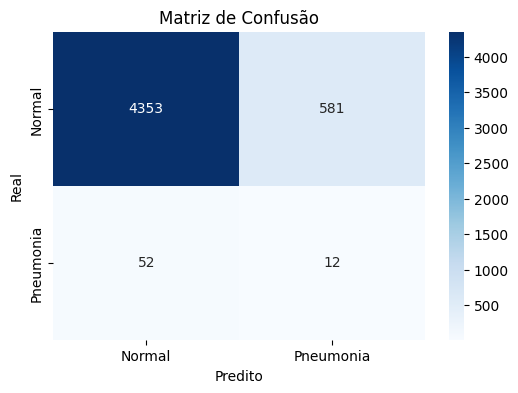

In [15]:
predizer_pasta("/content/drive/MyDrive/teste", predicar)


Acurácia:  0.8349358974358975
Predito como normal:  137
Predito como pneumonia:  487
Quantidade real de normal:  234
Quantidade real de pneumonia:  390

Acertos de Normal:  134
Acertos de Pneumonia:  387
Normal predito como pneumonia:  100
Pneumonia predito como normal:  3


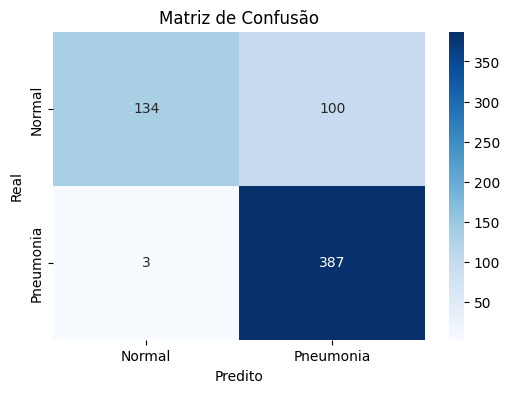

In [16]:
predizer_pasta("/content/drive/MyDrive/kaggle/test", predicar)


Acurácia:  0.9804447852760736
Predito como normal:  1391
Predito como pneumonia:  3825
Quantidade real de normal:  1341
Quantidade real de pneumonia:  3875

Acertos de Normal:  1315
Acertos de Pneumonia:  3799
Normal predito como pneumonia:  26
Pneumonia predito como normal:  76


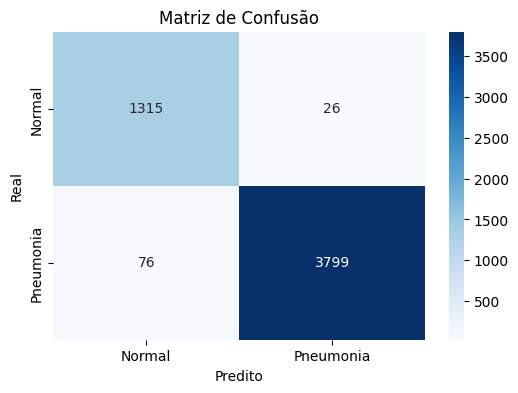

In [17]:
predizer_pasta('/content/drive/MyDrive/kaggle/train', predicar)